# Notebook Week 1






## Opdracht 1: Game Theory

In deze opdracht implementeer je strategiën in een game theory scenario.

In [1]:
import random
random.seed(0)

class Player:
    """
    Vertegenwoordigt een speler in het Prisoners Dillemma
    """
    def __init__(self, name, strategy):
        """
        Initializeer een speler met naam en strategie.
        :param name: Player's name
        :param strategy: A callable function implementing the strategy
        """
        self.name = name
        self.strategy = strategy
        self.history = []

    def make_move(self, opponent_history):
        """
        Bepaal de volgende "move"/zet op basis van de strategie.
        :param opponent_history: List of opponent's past moves
        :return: 'C' (Cooperate) or 'D' (Defect)
        """
        return self.strategy(self.history, opponent_history)

    def update_history(self, move):
        """
        Update de historie van een speler door er de laatste "move"/zet aan toe te voegen.
        :param move: 'C' or 'D'
        """
        self.history.append(move)

class RepeatedPrisonersDilemma:
    """
    Class die het Repeated Prisoner's Dilemma mogelijk maakt.
    """
    def __init__(self, player1, player2, rounds=10):
        """
        Initializeer het spel.
        :param player1: Speler 1 (Player object)
        :param player2: Speler 2 (Player object)
        :param rounds: Aantal rondes dat gespeeld wordt.
        """
        self.player1 = player1
        self.player2 = player2
        self.rounds = rounds
        self.history = []

    def play_round(self):
        """
        Speel een enkele ronde van het spel.
        """
        move1 = self.player1.make_move(self.player2.history)
        move2 = self.player2.make_move(self.player1.history)
        self.player1.update_history(move1)
        self.player2.update_history(move2)
        self.history.append((move1, move2))
        return move1, move2

    def play_game(self):
        """
        Speelt alle rondes van het spel.
        :return: Een tuple met de totale scores voor elke speler.
        """
        scores = {self.player1.name: 0, self.player2.name: 0}
        for _ in range(self.rounds):
            move1, move2 = self.play_round()
            if move1 == 'C' and move2 == 'C':
                scores[self.player1.name] += 3
                scores[self.player2.name] += 3
            elif move1 == 'C' and move2 == 'D':
                scores[self.player2.name] += 5
            elif move1 == 'D' and move2 == 'C':
                scores[self.player1.name] += 5
            elif move1 == 'D' and move2 == 'D':
                scores[self.player1.name] += 1
                scores[self.player2.name] += 1
        return scores

## Aantal voorbeeld strategiën
def tit_for_tat(my_history, opponent_history):
    """
    A Tit-for-Tat strategy: begint met samenwerking en spiegelt de laatste zet van de tegenstander.
    """
    if not opponent_history:
        return 'C'
    return opponent_history[-1]


def always_cooperate(my_history, opponent_history):
    """
    Altijd cooperate strategie
    """
    return 'C'


def always_defect(my_history, opponent_history):
    """
    Altijd defect strategie.
    """
    return 'D'


def random_strategy(my_history, opponent_history):
    """
    Random strategy: Kies willekeurig tussen cooperate en defect.
    """
    return random.choice(['C', 'D'])


1. Teken de pay-off matrix van dit spel.

2. Wat is het Nash Equilibrium?

3. Implementeer minstens 2 andere zelf bedachte strategieën en 2 strategieën die je kunt vinden in de literatuur. Inspecteer hoe deze strategieën presteren tegen de volgende strategiën :

- (a) Tit-For-Tat strategy
- (b) Always Cooperate
- (c) Always Defect
- (d) Random Strategy



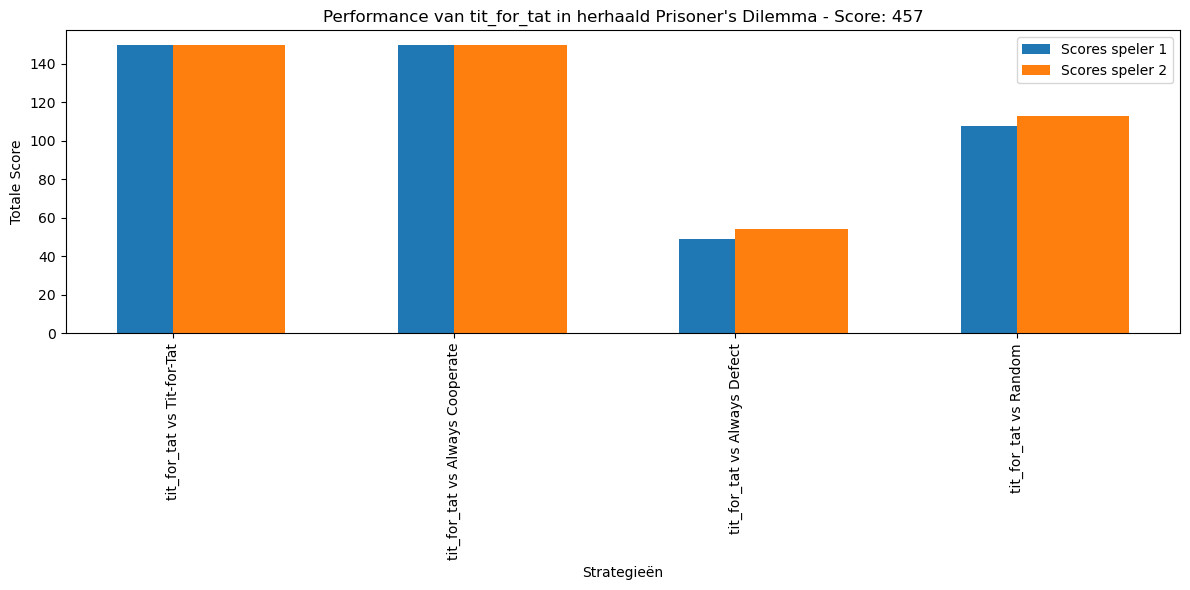

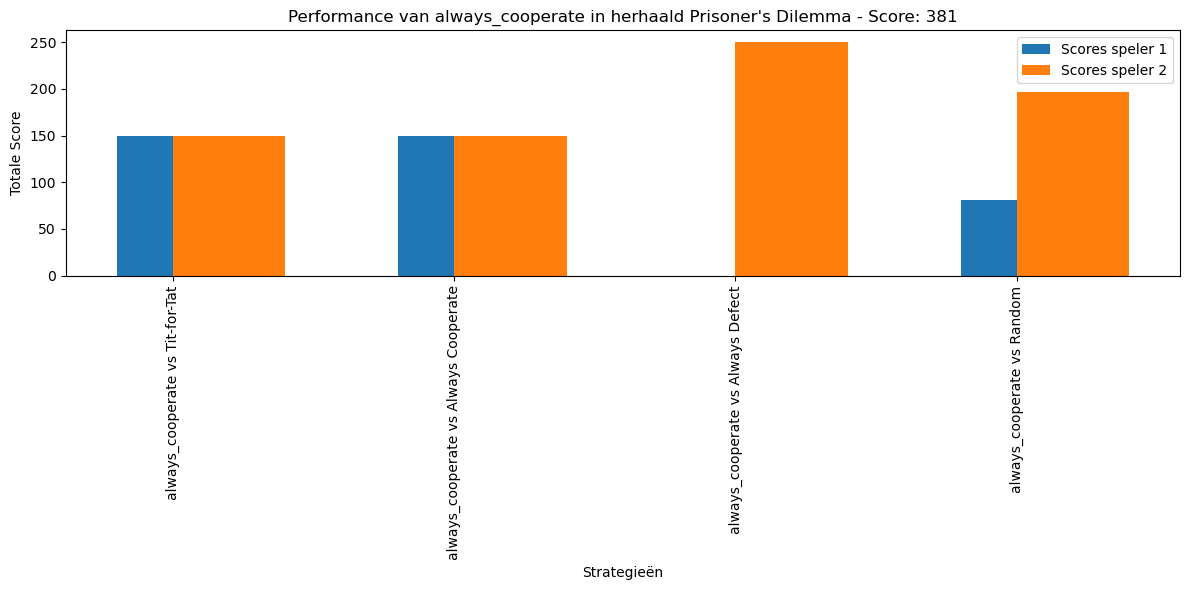

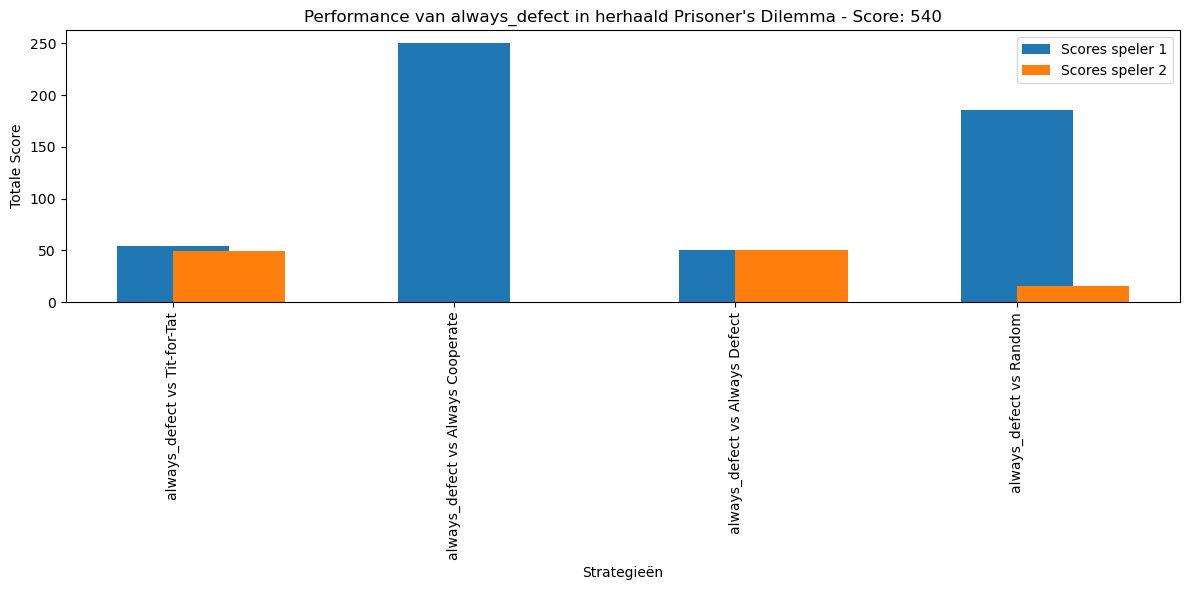

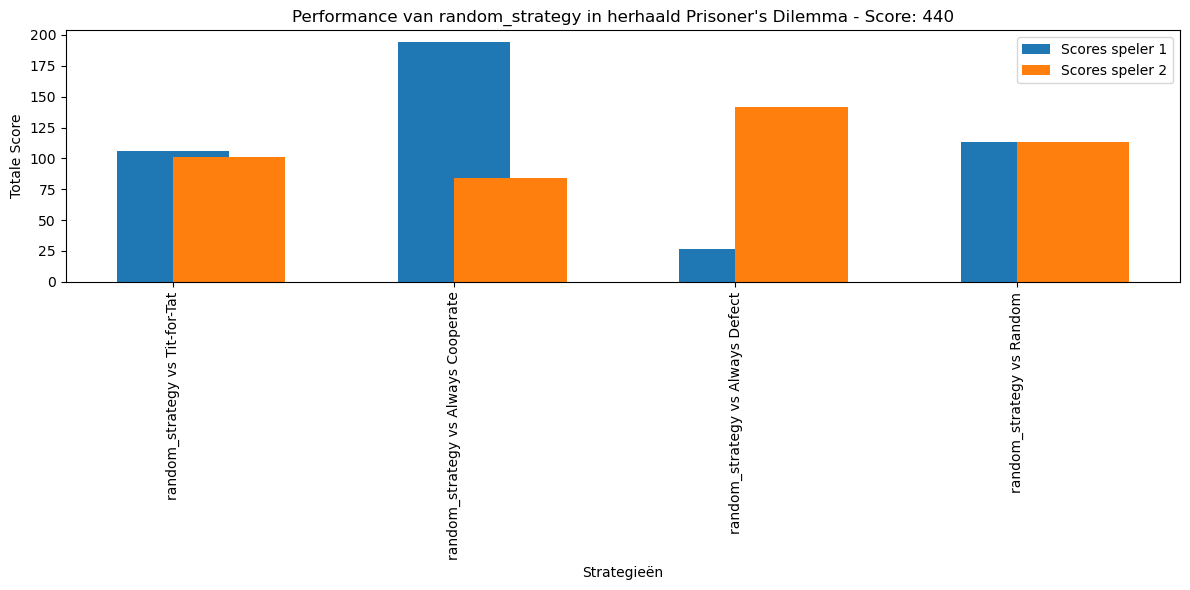

In [2]:
import matplotlib.pyplot as plt

STRATEGIES = {
        ### NOEM JOUW GEIMPLEMENTEERDE STRATEGIEËN HIER
        "Tit-for-Tat": tit_for_tat,
        "Always Cooperate": always_cooperate,
        "Always Defect": always_defect,
        "Random": random_strategy,
    }

## IMPLEMENTEER JE STRATEGIEËN HIER

def run_scenarios(function):

    rounds = 50  # Rondes per scenario
    results = []

    strat1_naam = f"{function.__name__}"
    strat1 = function

    for strat2_naam, strat2 in STRATEGIES.items():
        player1 = Player("Player 1 (" + strat1_naam + ")", strat1)
        player2 = Player("Player 2 (" + strat2_naam + ")", strat2)
        game = RepeatedPrisonersDilemma(player1, player2, rounds)
        scores = game.play_game()
        results.append((strat1_naam, strat2_naam, scores))
    return results

# Visualiseer resultaten
def plot_resultaten(results):
    strategy_combinations = []
    s1_scores = []
    s2_scores = []

    for strat1_naam, strat2_naam, scores in results:
        strategy_combinations.append(f"{strat1_naam} vs {strat2_naam}")
        s1_scores.append(scores["Player 1 (" + strat1_naam + ")"])
        s2_scores.append(scores["Player 2 (" + strat2_naam + ")"])

    x = range(len(strategy_combinations))
    plt.figure(figsize=(12, 6))
    plt.bar(x, s1_scores, width=0.4, label='Scores speler 1', align='center')
    plt.bar(x, s2_scores, width=0.4, label='Scores speler 2', align='edge')
    plt.xticks(x, strategy_combinations, rotation=90)
    plt.ylabel("Totale Score")
    plt.xlabel("Strategieën")
    plt.title(f"Performance van {strat1_naam} in herhaald Prisoner's Dilemma - Score: {sum(s1_scores)}")
    plt.legend()
    plt.tight_layout()
    plt.show()

import types

function_list = [strategy for name, strategy in STRATEGIES.items() if callable(strategy)]

# Run scenarios and plot results
for function in function_list:
  results = run_scenarios(function)
  plot_resultaten(results)

4. Wat is het hoogste score totaal wat je kunt halen tegen de 4 strategiën?

## Opdracht 2: Werken met Inference Engines

### Uitleg
Onderstaande code demonstreert hoe je de **Durable Rules** package kunt gebruiken, samen met een aangepaste uitbreiding `durable_rules_tools`, om een eenvoudig rule based system te maken en te beheren. Het laat zien hoe je een **ruleset** definieert, logische voorwaarden voor regels specificeert, en feiten verwerkt.

---

**Belangrijkste Componenten:**

##### 1. **Durable Rules Framework**
- **Ruleset:** Een verzameling regels die werken met feiten.
- **Feiten:** Data-items (gestructureerd als dictionaries) die door de regels worden geëvalueerd en verwerkt.
- **Voorwaarden en Acties:** Elke regel specificeert een voorwaarde (wanneer deze van toepassing is) en een actie (wat er gebeurt).

##### 2. **Imports:**
```python
from durable.lang import ruleset, when_all, assert_fact, c, m, post
```
- **`ruleset`:** Definieert een nieuwe regelset.
- **`when_all`:** Specificeert voorwaarden voor een regel met logische expressies.
- **`assert_fact`:** Voegt een nieuw feit toe aan het werkgeheugen.
- **`c` en `m`:** Hulpobjecten voor context en matching:
  - **`c`:** Context van de regel, staat acties toe zoals het toevoegen of verwijderen van feiten.
  - **`m`:** Matcher voor de binnenkomende feitgegevens.

##### 3. **Aangepast Hulppakket (`durable_rules_tools`)**
Dit pakket voegt hulpfuncties toe zoals:
- **`new_ruleset`:** Snel een unieke ruleset-naam genereren.

### Example

In [3]:
pip install durable_rules

  Using cached durable_rules-2.0.28.tar.gz (57 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Running setup.py clean for durable_rules
Failed to build durable_rules
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'durable_rules' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'durable_rules'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build
      creating build\lib.win-amd64-cpython-312
      creating build\lib.win-amd64-cpython-312\durable
      copying libpy\durable\engine.py -> build\lib.win-amd64-cpython-312\durable
      copying libpy\durable\lang.py -> build\lib.win-amd64-cpython-312\durable
      copying libpy\durable\__init_

In [4]:
pip install durable_rules_tools

  Using cached durable_rules_tools-0.0.1-py3-none-any.whl.metadata (1.5 kB)
  Using cached durable_rules-2.0.28.tar.gz (57 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Using cached durable_rules_tools-0.0.1-py3-none-any.whl (5.1 kB)
  Running setup.py clean for durable-rules
Failed to build durable-rules
Note: you may need to restart the kernel to use updated packages.


  DEPRECATION: Building 'durable-rules' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'durable-rules'. Discussion can be found at https://github.com/pypa/pip/issues/6334
  error: subprocess-exited-with-error
  
  × python setup.py bdist_wheel did not run successfully.
  │ exit code: 1
  ╰─> [12 lines of output]
      running bdist_wheel
      running build
      running build_py
      creating build
      creating build\lib.win-amd64-cpython-312
      creating build\lib.win-amd64-cpython-312\durable
      copying libpy\durable\engine.py -> build\lib.win-amd64-cpython-312\durable
      copying libpy\durable\lang.py -> build\lib.win-amd64-cpython-312\durable
      copying libpy\durable\__init_

In [5]:
from durable.lang import ruleset, when_all, assert_fact, c, m, post
from durable_rules_tools.rules_utils import new_ruleset, Set, Subject

%reload_ext durable_rules_tools

ModuleNotFoundError: No module named 'durable'

In [ ]:
# Hier wordt een simpele ruleset gemaakt
EVENTRULESET = new_ruleset()
with ruleset(EVENTRULESET):
    @when_all(m.color=='red')
    def see_red(c):
        print(f'I see red')
        c.assert_fact({'status': 'danger'})

    @when_all(m.color!='red')
    def not_red(c):
        print(f'I see {c.m.color}')
        c.assert_fact({'status': 'safe'})

    @when_all( m.status == 'danger')
    def dangerous(c):
        print(f'That is dangerous.')
        c.retract_fact({'status': 'danger'})

    @when_all( m.status == 'safe')
    def safe(c):
        print(f'That is safe.')
        c.retract_fact({'status': 'safe'})

In [ ]:
assert_fact(EVENTRULESET, {'color': 'red'})

I see red
That is dangerous.


{'sid': '0', 'id': 'sid-0', '$s': 1}

### Opdracht deel 1
---



**Doelstelling**

Leer hoe je basis regels kunt maken en gebruiken met het **durable-rules** pakket door een eenvoudig systeem te implementeren dat weersomstandigheden classificeert op basis van waarneembare feiten.



**Scenario**

You are tasked with building a basic rule-based system to classify the weather as **Warm and Sunny**, **Rainy**, or **Stormy** based on the following observable facts:  
1. **Temperature**: Continuous value (e.g., 30°C, 10°C).  
2. **Rainfall**: Boolean (`True` if it is raining, otherwise `False`).  
3. **Wind Speed**: Continuous value (e.g., 15 km/h, 50 km/h).

---



Maak een rulebased systeem om het weer te classificeren als **Warm en Zonnig**, **Regenachtig**, of **Stormachtig** op basis van de volgende waarneembare feiten:
1. **Temperatuur**: Continue waarde (bijv. 30°C, 10°C).
2. **Regenval**: Boolean (`True` als het regent, anders `False`).
3. **Windsnelheid**: Continue waarde (bijv. 15 km/u, 50 km/u).


**To Do:**
1. **Definieer Basisregels**:
   Gebruik de durable-rules package om de volgende regels te maken:
   - **Warm en Zonnig**: Temperatuur > 25°C en geen regenval.
   - **Regenachtig**: Regenval is `True` en windsnelheid < 20 km/u.
   - **Stormachtig**: Regenval is `True` en windsnelheid ≥ 20 km/u.

2. **Implementeer Regels**:
   Schrijf de regels in Python met durable-rules en zorg ervoor dat het systeem de weersconditie print wanneer deze overeenkomt met een regel.

3. **Test Je Regels**:
   Zorg voor drie testscenario's met waarneembare feiten, en controleer of het systeem de weersconditie correct classificeert.

In [ ]:
# IMPLEMENTEER JE CODE HIER


### **Opdracht deel 2**  
Nu:
- Voeg nieuwe waarneembare feiten toe, zoals luchtvochtigheid of bewolking, om classificaties te verfijnen.
- Pas regels aan of breid ze uit, zoals het maken van een "Bewolkt" classificatie.

In [ ]:
# IMPLEMENTEER JE CODE HIER